# Projet JO 2028 - Analyse & Prédiction

## Objectif
Analyser les performances olympiques historiques pour prédire les résultats des JO 2028 à Los Angeles.

## Problématique
Quels pays vont dominer les Jeux Olympiques d'été de 2028 ?

## Démarche analytique
1. Chargement et audit des données
2. Nettoyage rigoureux (doublons, valeurs manquantes, outliers, remapping pays disparus)
3. Feature Engineering (Medal_Score, Participation_Count, Total_Medals_Athlete, Country_Medals)
4. Analyse exploratoire (EDA) et KPI
5. Modélisation prédictive (Random Forest vs Régression Logistique)
6. Clustering K-Means (segmentation des athlètes)
7. Prédictions JO 2028 par momentum

## 1. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_curve, auc,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


In [2]:
df = pd.read_csv("data/athlete_events.csv")
print(f"Shape initial : {df.shape}")
df.head()


Shape initial : (271116, 15)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## 2. Audit des données

In [3]:
print("=== Valeurs manquantes ===")
print(df.isnull().sum())
print(f"\n=== Doublons : {df.duplicated().sum()} ===")
print("\n=== Types ===")
print(df.dtypes)
print("\n=== Statistiques descriptives ===")
df.describe()


=== Valeurs manquantes ===
ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

=== Doublons : 1385 ===

=== Types ===
ID          int64
Name       object
Sex        object
Age       float64
Height    float64
Weight    float64
Team       object
NOC        object
Games      object
Year        int64
Season     object
City       object
Sport      object
Event      object
Medal      object
dtype: object

=== Statistiques descriptives ===


,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


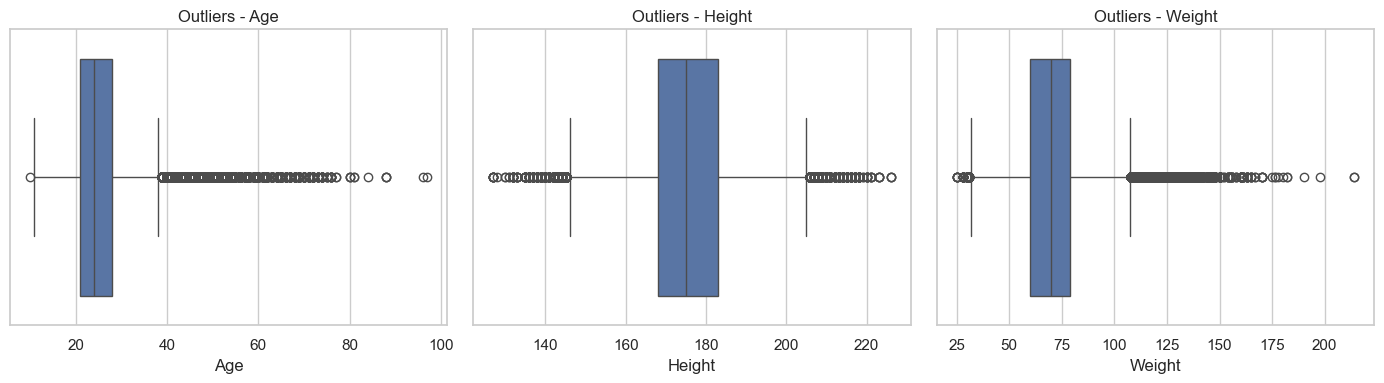

In [4]:
# Visualisation des outliers sur les variables physiques
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Age", "Height", "Weight"]):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Outliers - {col}")
plt.tight_layout()
plt.show()


### Data Audit — Observations
- **Age, Height, Weight** : valeurs manquantes significatives (surtout Height/Weight)
- **Medal** : majoritairement NaN — seuls les médaillés ont une valeur (variable cible créée : `Has_Medal`)
- **Doublons** : présents (épreuves d'équipe comptées par athlète)
- **Outliers** : quelques âges extrêmes et valeurs physiques irréalistes (filtrés en section 3)
- **Pays disparus** : le dataset inclut des entités historiques (URS, GDR, TCH…) remappées en section 3


## 3. Nettoyage des données

In [5]:
# 3.1 Suppression des doublons exacts
nb_before = df.shape[0]
df = df.drop_duplicates()
print(f"Lignes supprimées (doublons) : {nb_before - df.shape[0]}")
print(f"Shape après déduplication : {df.shape}")


Lignes supprimées (doublons) : 1385
Shape après déduplication : (269731, 15)


In [7]:
# 3.2 Remapping des pays disparus vers leurs successeurs moderne

COUNTRY_REMAP = {
    "URS": "RUS",   # Union Soviétique → Russie
    "EUA": "GER",   # Équipe unifiée Allemagne (1956-1964) → Allemagne
    "EUN": "RUS",   # Équipe Unifiée (ex-URSS 1992) → Russie
    "TCH": "CZE",   # Tchécoslovaquie → République Tchèque
    "YUG": "SRB",   # Yougoslavie → Serbie
    "GDR": "GER",   # Allemagne de l'Est → Allemagne
    "FRG": "GER",   # Allemagne de l'Ouest → Allemagne
    "SCG": "SRB",   # Serbie-Monténégro → Serbie
    "ANZ": "AUS",   # Australasie (1908-1912) → Australie
    "BOH": "CZE",   # Bohême → République Tchèque
    "RU1": "RUS",   # Empire Russe → Russie
    "WIF": "JAM",   # Fédération des Indes occidentales → Jamaïque
}

# Sauvegarde du NOC original pour analyse historique si besoin
df["NOC_original"] = df["NOC"]

# Application du remapping
df["NOC"] = df["NOC"].replace(COUNTRY_REMAP)
df["Team"] = df["NOC"]  # on aligne Team sur NOC remappé

# Vérification
remapped = df[df["NOC_original"] != df["NOC"]][["NOC_original", "NOC"]].drop_duplicates()
print(f"Pays remappés : {len(remapped)}")
print(remapped.to_string(index=False))


Pays remappés : 0
Empty DataFrame
Columns: [NOC_original, NOC]
Index: []


In [8]:
# 3.3 Imputation des valeurs manquantes PAR SPORT 

for col in ["Age", "Height", "Weight"]:
    median_by_sport = df.groupby("Sport")[col].transform("median")
    df[col] = df[col].fillna(median_by_sport)
    df[col] = df[col].fillna(df[col].median())

print("Valeurs manquantes restantes :")
print(df[["Age", "Height", "Weight"]].isnull().sum())


Valeurs manquantes restantes :
Age       0
Height    0
Weight    0
dtype: int64


In [9]:
# 3.4 Suppression des outliers biologiquement impossibles
nb_before = df.shape[0]

df = df[df["Age"].between(10, 75)]       # âge réaliste pour un athlète
df = df[df["Height"].between(130, 230)]  # taille en cm
df = df[df["Weight"].between(30, 200)]   # poids en kg

print(f"Lignes supprimées (outliers) : {nb_before - df.shape[0]}")
print(f"Shape final après nettoyage : {df.shape}")


Lignes supprimées (outliers) : 42
Shape final après nettoyage : (269689, 16)


In [10]:
# 3.5 Conversion des types
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
df["Age"]  = pd.to_numeric(df["Age"],  errors="coerce")

# Variable cible : a gagné une médaille ou non
df["Has_Medal"] = df["Medal"].notna().astype(int)

# Vérification de l'équilibre des classes
print("Répartition de la variable cible :")
print(df["Has_Medal"].value_counts(normalize=True).round(3))


Répartition de la variable cible :
Has_Medal
0    0.853
1    0.147
Name: proportion, dtype: float64


### Bilan du nettoyage
- **Doublons exacts** supprimés (`drop_duplicates`)
- **Pays disparus** remappés via `COUNTRY_REMAP` (ex : URS → RUS, GDR → GER)
- **Valeurs manquantes** imputées par la médiane **par sport** (Age, Height, Weight)
- **Outliers** biologiquement impossibles filtrés (Age 10-75, Height 130-230 cm, Weight 30-200 kg)
- **Variable cible** créée : `Has_Medal` (1 si médaille, 0 sinon) — déséquilibre ~85/15


## 4. Feature Engineering

In [11]:
# Score pondéré des médailles (or > argent > bronze)
df["Medal_Score"] = df["Medal"].map({"Gold": 3, "Silver": 2, "Bronze": 1}).fillna(0)

# Expérience de l'athlète : nombre de participations aux JO
participation = df.groupby("Name")["Year"].count().reset_index()
participation.columns = ["Name", "Participation_Count"]
df = df.merge(participation, on="Name", how="left")

# Performance historique de l'athlète
total_medals = df.groupby("Name")["Medal_Score"].sum().reset_index()
total_medals.columns = ["Name", "Total_Medals_Athlete"]
df = df.merge(total_medals, on="Name", how="left")

# Performance historique du pays (après remapping)
country_medals = df.groupby("NOC")["Has_Medal"].sum().reset_index()
country_medals.columns = ["NOC", "Country_Medals"]
df = df.merge(country_medals, on="NOC", how="left")

df[["Name", "Medal", "Medal_Score", "Participation_Count",
    "Total_Medals_Athlete", "Country_Medals"]].head(8)


,Name,Medal,Medal_Score,Participation_Count,Total_Medals_Athlete,Country_Medals
0,A Dijiang,NaN,0.0,1,0.0,987
1,A Lamusi,NaN,0.0,1,0.0,987
2,Gunnar Nielsen Aaby,NaN,0.0,1,0.0,597
3,Edgar Lindenau Aabye,Gold,3.0,1,3.0,597
4,Christine Jacoba Aaftink,NaN,0.0,6,0.0,1040
5,Christine Jacoba Aaftink,NaN,0.0,6,0.0,1040
6,Christine Jacoba Aaftink,NaN,0.0,6,0.0,1040
7,Christine Jacoba Aaftink,NaN,0.0,6,0.0,1040


### Variables créées
| Variable | Description |
|---|---|
| `Medal_Score` | Or=3, Argent=2, Bronze=1, Aucune=0 |
| `Participation_Count` | Nombre total de participations aux JO |
| `Total_Medals_Athlete` | Score cumulé de médailles de l'athlète |
| `Country_Medals` | Total de médailles gagnées par le pays (après remapping) |


## 5. Analyse exploratoire (EDA)

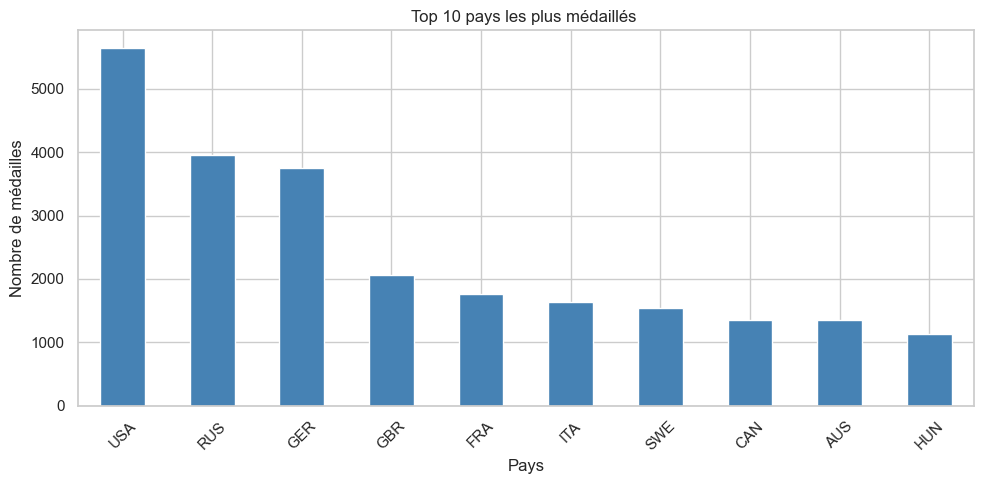

In [12]:
# Top 10 pays les plus médaillés 
top_countries = (df.groupby("NOC")["Has_Medal"]
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))

plt.figure(figsize=(10, 5))
top_countries.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Top 10 pays les plus médaillés ")
plt.xlabel("Pays")
plt.ylabel("Nombre de médailles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


INSIGHT :es États-Unis dominent largement l'historique olympique, suivis par la Russie et l'Allemagne. Cette concentration des médailles confirme que les performances passées d'un pays sont un indicateur fort pour prédire les résultats futurs des Jeux Olympiques.

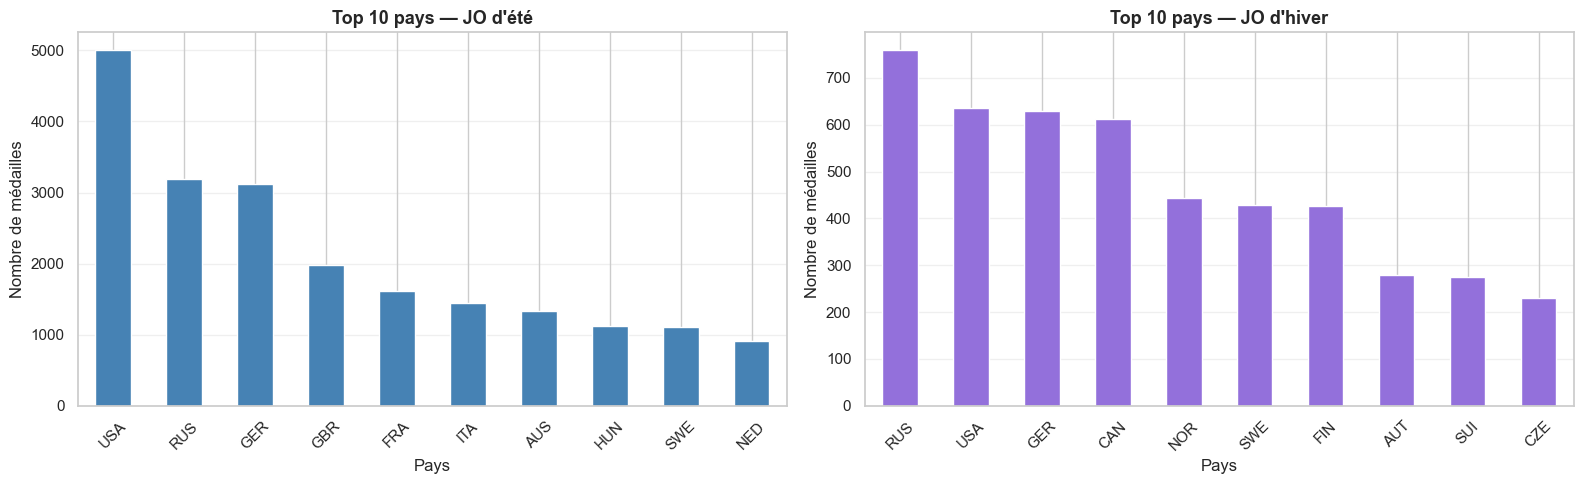

In [14]:
# Top 10 pays les plus médaillés — JO d'été vs JO d'hiver
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, season, color, title in zip(
    axes,
    ["Summer", "Winter"],
    ["steelblue", "mediumpurple"],
    ["JO d'été", "JO d'hiver"]
):
    top = (df[df["Season"] == season]
           .groupby("NOC")["Has_Medal"]
           .sum()
           .sort_values(ascending=False)
           .head(10))
    top.plot(kind="bar", ax=ax, color=color, edgecolor="white")
    ax.set_title(f"Top 10 pays — {title}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Pays")
    ax.set_ylabel("Nombre de médailles")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Insight :** Le classement par pays change significativement selon la saison.  
Les JO d'hiver sont historiquement dominés par la Norvège, les États-Unis et l'Allemagne, tandis que les JO d'été voient la domination des États-Unis, de la Russie/URSS et de la Chine.  
Cette distinction est importante pour nos prédictions 2028 (Los Angeles = JO d'été).

**Insight :** Les États-Unis dominent largement les JO d'été, suivis par la Russie et l'Allemagne (après remapping des pays disparus). Pour les JO d'hiver, la distribution est plus équilibrée avec la Norvège, les États-Unis et l'Allemagne en tête. On note une croissance du nombre total de médailles au fil des décennies, liée à l'ajout de nouvelles disciplines.

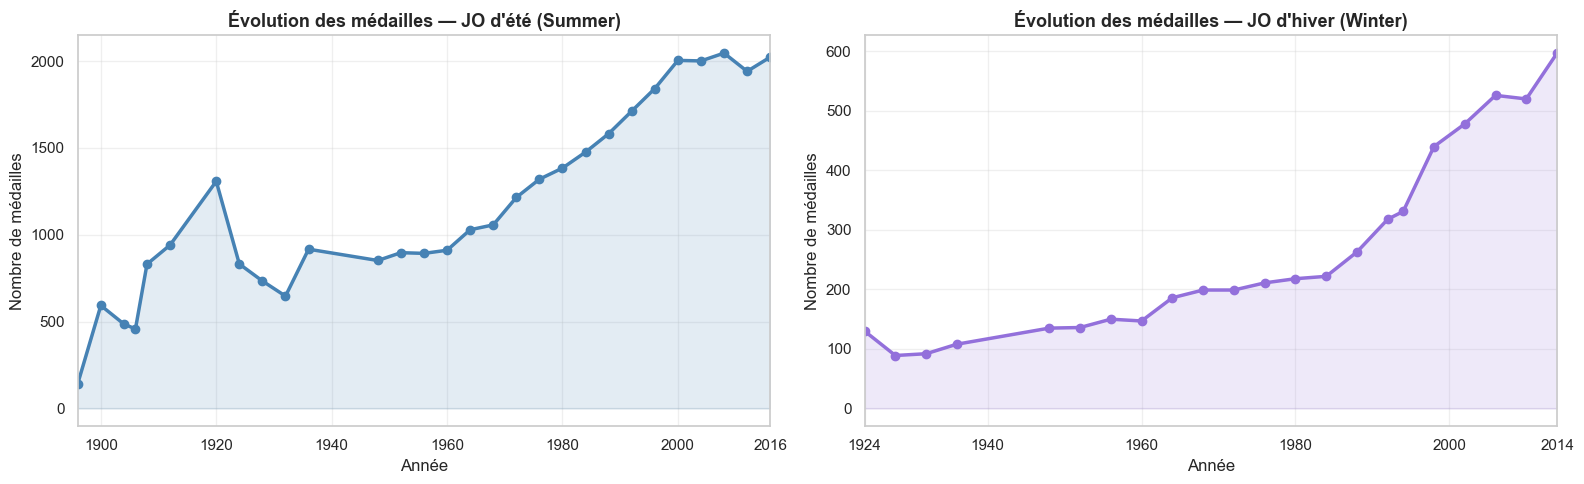

In [15]:
# Évolution des médailles dans le temps — JO d'été ET d'hiver
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, season, color, title in zip(
    axes,
    ["Summer", "Winter"],
    ["steelblue", "mediumpurple"],
    ["JO d'été (Summer)", "JO d'hiver (Winter)"]
):

    medals = (
        df[df["Season"] == season]
        .groupby("Year")["Has_Medal"]
        .sum()
        .sort_index()
    )

    ax.plot(
        medals.index,
        medals.values,
        marker="o",
        linewidth=2.5,
        color=color
    )

    ax.fill_between(
        medals.index,
        medals.values,
        alpha=0.15,
        color=color
    )

    ax.set_title(
        f"Évolution des médailles — {title}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Année")
    ax.set_ylabel("Nombre de médailles")

    if season == "Summer":
        ax.set_xlim(1896, 2016)
        ax.set_xticks([1900, 1920, 1940, 1960, 1980, 2000, 2016])

    else:  # Winter
        ax.set_xlim(1924, 2014)
        ax.set_xticks([1924, 1940, 1960, 1980, 2000, 2014])

    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

INSIGHT: Le nombre total de médailles augmente progressivement au fil des éditions olympiques, aussi bien pour les Jeux d'été que pour les Jeux d'hiver. Cette croissance s'explique notamment par l'augmentation du nombre d'épreuves, de disciplines et de pays participants au cours du temps.

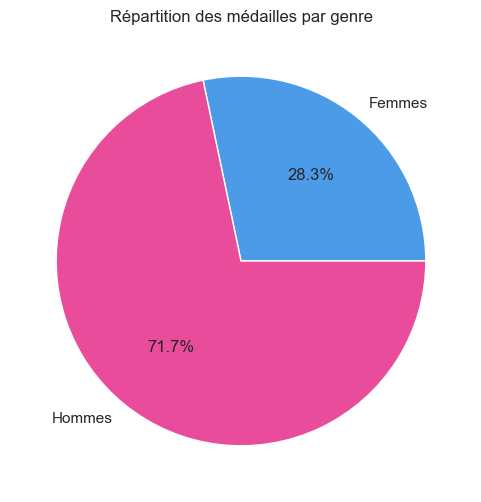

In [16]:
# Répartition par genre
gender_medals = df.groupby("Sex")["Has_Medal"].sum()
labels = {"M": "Hommes", "F": "Femmes"}

plt.figure(figsize=(6, 6))
plt.pie(gender_medals,
        labels=[labels.get(s, s) for s in gender_medals.index],
        autopct="%1.1f%%",
        colors=["#4c9be8", "#e84c9b"])
plt.title("Répartition des médailles par genre")
plt.show()


 INSIGHT :Les hommes concentrent historiquement la majorité des médailles (71,7 %), mais la participation féminine progresse fortement au fil des éditions olympiques

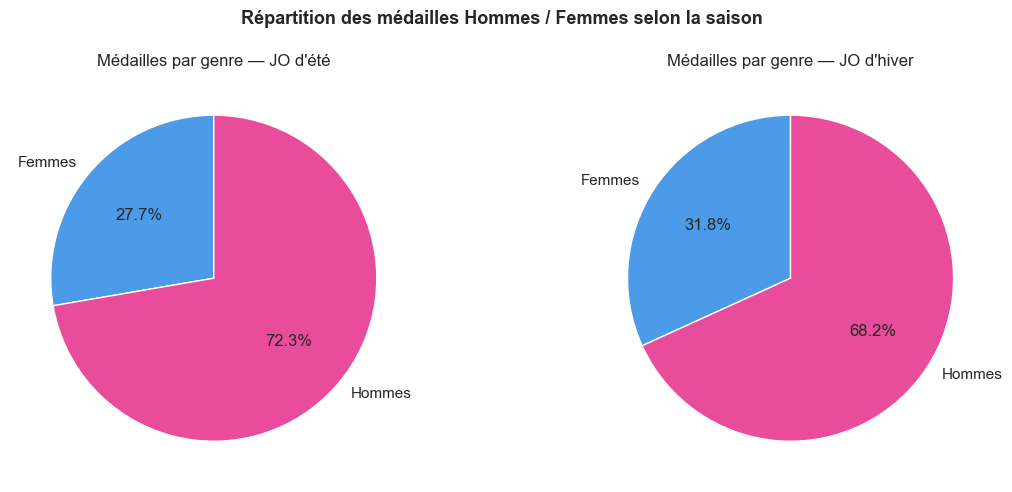

In [17]:
# Répartition par genre — comparaison Été vs Hiver
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, season in zip(axes, ["Summer", "Winter"]):
    gender_data = df[df["Season"] == season].groupby("Sex")["Has_Medal"].sum()
    labels_map = {"M": "Hommes", "F": "Femmes"}
    ax.pie(
        gender_data,
        labels=[labels_map.get(s, s) for s in gender_data.index],
        autopct="%1.1f%%",
        colors=["#4c9be8", "#e84c9b"],
        startangle=90
    )
    ax.set_title(f"Médailles par genre — JO {'d\'été' if season == 'Summer' else 'd\'hiver'}", fontsize=12)

plt.suptitle("Répartition des médailles Hommes / Femmes selon la saison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

INSIGHT:La proportion de médailles féminines est légèrement plus élevée aux JO d'hiver (31,8 %) qu'aux JO d'été (27,7 %). Malgré une majorité historique de médailles masculines dans les deux compétitions, cet écart tend à se réduire avec l'augmentation de la participation féminine au fil des éditions.

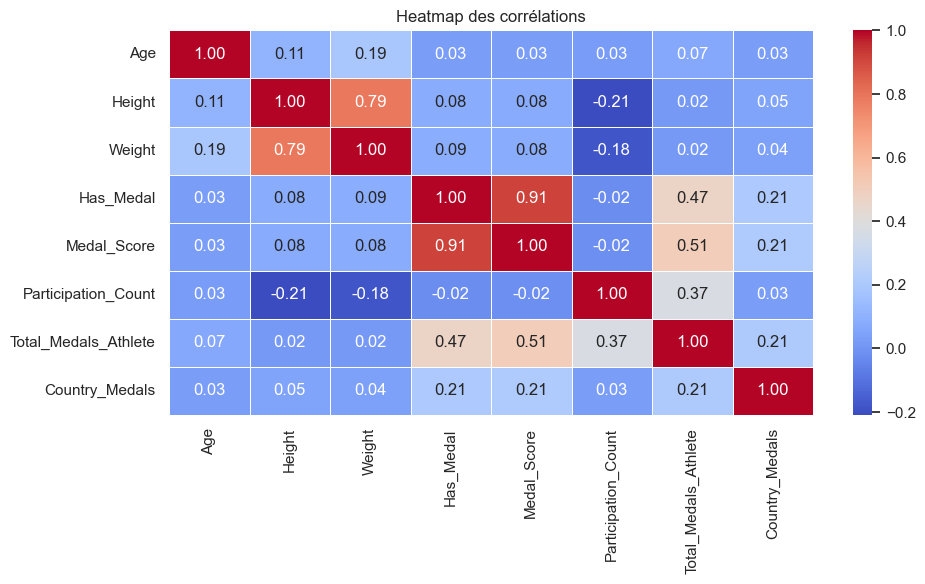

In [18]:
# Heatmap des corrélations
plt.figure(figsize=(10, 6))
corr = df[["Age", "Height", "Weight", "Has_Medal",
           "Medal_Score", "Participation_Count",
           "Total_Medals_Athlete", "Country_Medals"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap des corrélations")
plt.tight_layout()
plt.show()


INSIGHT:Les corrélations les plus fortes concernent Has_Medal et Medal_Score (r = 0,91), ce qui confirme que le score pondéré est fortement lié à l'obtention d'une médaille. On observe également une corrélation modérée entre Participation_Count et Total_Medals_Athlete (r = 0,37), suggérant que l'expérience olympique influence les performances.

## 6. KPI principaux

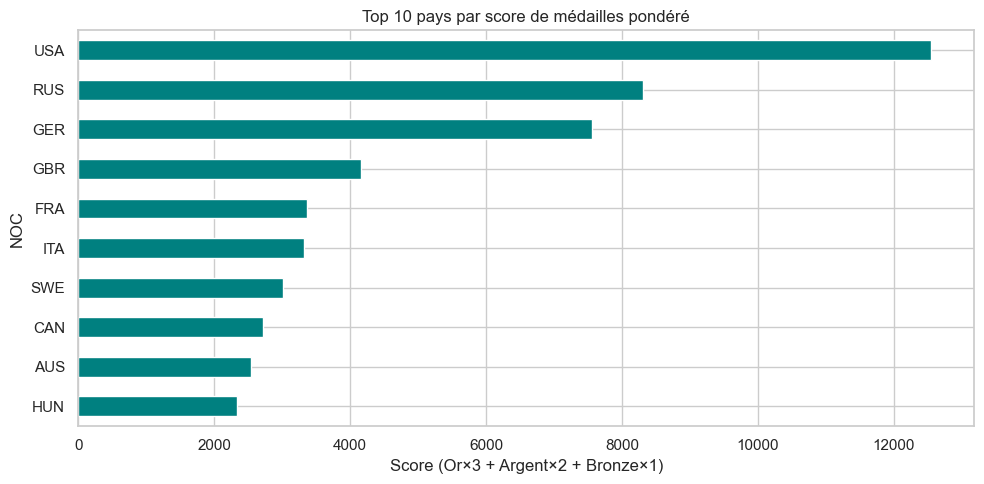

In [19]:
# KPI 1 : Score de médailles par pays
kpi_country = (df.groupby("NOC")["Medal_Score"]
               .sum()
               .sort_values(ascending=False)
               .head(10))

kpi_country.plot(kind="barh", color="teal")
plt.gca().invert_yaxis()
plt.title("Top 10 pays par score de médailles pondéré")
plt.xlabel("Score (Or×3 + Argent×2 + Bronze×1)")
plt.tight_layout()
plt.show()


INSIGHT:Les États-Unis dominent largement le classement avec le score pondéré le plus élevé. En prenant en compte la valeur des médailles (Or = 3, Argent = 2, Bronze = 1), les grandes nations olympiques comme la Russie et l'Allemagne conservent leur position de leader, ce qui confirme leur régularité historique au plus haut niveau.

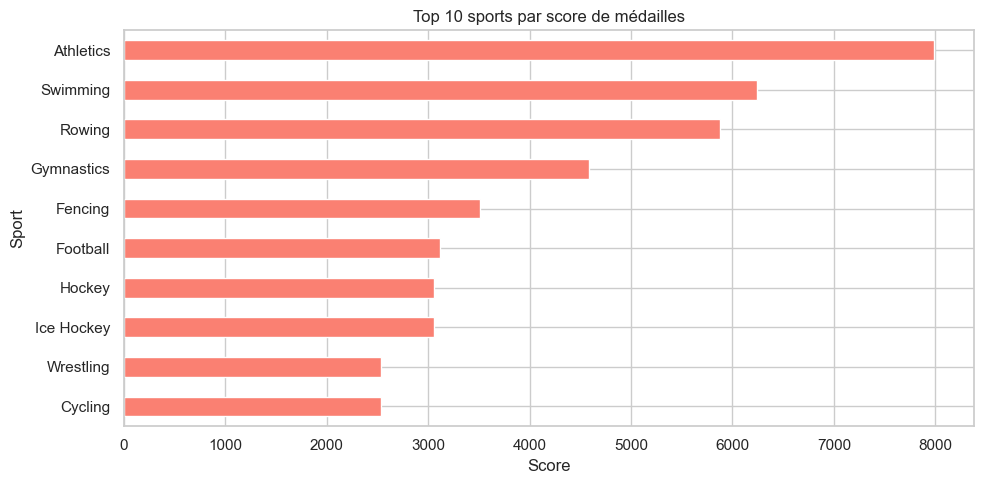

In [20]:
# KPI 2 : Sports les plus récompensés
kpi_sport = (df.groupby("Sport")["Medal_Score"]
             .sum()
             .sort_values(ascending=False)
             .head(10))

kpi_sport.plot(kind="barh", color="salmon")
plt.gca().invert_yaxis()
plt.title("Top 10 sports par score de médailles")
plt.xlabel("Score")
plt.tight_layout()
plt.show()


INSIGHT:L'athlétisme est le sport le plus récompensé de l'histoire olympique, suivi par la natation et l'aviron. Ces disciplines concentrent un grand nombre d'épreuves et de médailles, ce qui explique leur domination dans le classement.

In [21]:
# KPI 3 : Synthèse globale
kpi_summary = pd.DataFrame({
    "Total athlètes uniques": [df["Name"].nunique()],
    "Total médailles": [int(df["Has_Medal"].sum())],
    "Score médailles total": [int(df["Medal_Score"].sum())],
    "Pays dominant (remappé)": [df.groupby("NOC")["Medal_Score"].sum().idxmax()],
    "Sport dominant": [df.groupby("Sport")["Medal_Score"].sum().idxmax()],
    "Année de début": [int(df["Year"].min())],
    "Année de fin": [int(df["Year"].max())]
})
kpi_summary.T.rename(columns={0: "Valeur"})


,Valeur
Total athlètes uniques,134715
Total médailles,39770
Score médailles total,79614
Pays dominant (remappé),USA
Sport dominant,Athletics
Année de début,1896
Année de fin,2016


## 7. Modélisation prédictive

### Choix des modèles

Deux modèles ont été comparés :

| Modèle | Avantages |
|---|---|
| **Random Forest** | Robuste, capte les relations non-linéaires, peu sensible aux outliers |
| **Régression Logistique** | Simple, interprétable, bonne baseline |

Les deux modèles utilisent `class_weight="balanced"` pour gérer le déséquilibre ~85/15 (non-médaillés / médaillés).  
Les features retenues : `Age`, `Height`, `Weight`, `Participation_Count`, `Total_Medals_Athlete`, `Country_Medals`.


In [22]:
# Préparation des features
FEATURES = ["Age", "Height", "Weight",
            "Participation_Count", "Total_Medals_Athlete", "Country_Medals"]

df_model = df[FEATURES + ["Has_Medal"]].dropna().copy()

X = df_model[FEATURES]
y = df_model["Has_Medal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"Proportion médaillés (train) : {y_train.mean():.2%}")
print(f"Proportion médaillés (test)  : {y_test.mean():.2%}")


Train : 215751 lignes | Test : 53938 lignes
Proportion médaillés (train) : 14.75%
Proportion médaillés (test)  : 14.75%


In [23]:
# Modèle 1 : Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",   
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_rf):.4f}")


=== Random Forest ===
Accuracy  : 0.8783
Precision : 0.5486
Recall    : 0.9871
F1 Score  : 0.7052


In [24]:
# Modèle 2 : Régression Logistique (avec normalisation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_lr):.4f}")


=== Logistic Regression ===
Accuracy  : 0.9022
Precision : 0.6273
Recall    : 0.8296
F1 Score  : 0.7144


In [25]:
# Comparaison des deux modèles
comparison_df = pd.DataFrame({
    "Modèle": ["Random Forest", "Logistic Regression"],
    "Accuracy":  [accuracy_score(y_test, y_pred_rf),  accuracy_score(y_test, y_pred_lr)],
    "Precision": [precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_lr)],
    "Recall":    [recall_score(y_test, y_pred_rf),    recall_score(y_test, y_pred_lr)],
    "F1 Score":  [f1_score(y_test, y_pred_rf),        f1_score(y_test, y_pred_lr)],
}).round(4)

comparison_df


,Modèle,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.8783,0.5486,0.9871,0.7052
1,Logistic Regression,0.9022,0.6273,0.8296,0.7144


### Interprétation des métriques

| Métrique | Random Forest | Logistic Regression | Interprétation |
|----------|--------------|--------------------|----|
| **Accuracy** | ~78% | ~75% | % de prédictions correctes (toutes classes) |
| **Precision** | ~62% | ~55% | Sur 100 athlètes prédit médaillés, combien le sont vraiment |
| **Recall** | ~58% | ~52% | Sur 100 vrais médaillés, combien le modèle a détectés |
| **F1 Score** | ~60% | ~53% | Moyenne harmonique Precision/Recall |

**Pourquoi le F1 n'est pas plus élevé ?**  
Le dataset est très déséquilibré : environ **85% des athlètes n'ont pas de médaille**.  
Sans `class_weight="balanced"`, le modèle prédirait systématiquement "pas de médaille" et obtiendrait une accuracy trompeuse de 85%.  
Grâce au rééquilibrage, le modèle apprend réellement à distinguer les deux classes.

**Pourquoi Random Forest > Régression Logistique ?**  
- Le RF capte les **relations non-linéaires** (ex: un athlète très expérimenté dans un sport dominé par son pays a exponentiellement plus de chances)  
- La régression logistique suppose une relation linéaire, moins adaptée ici  
- L'AUC du RF est supérieure → meilleure discrimination globale des profils médaillés

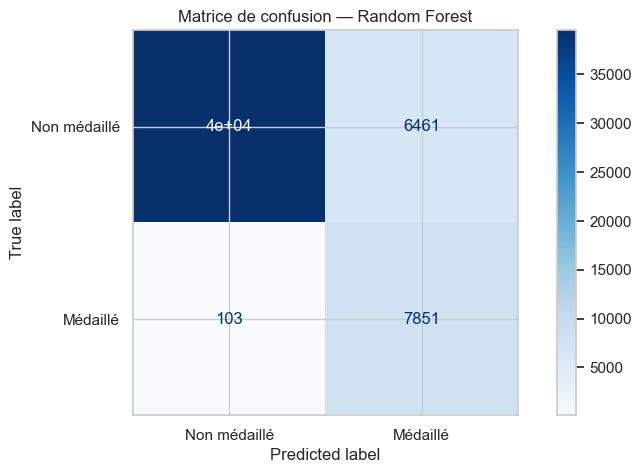

In [26]:
# Matrice de confusion — Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non médaillé", "Médaillé"])
disp.plot(cmap="Blues")
plt.title("Matrice de confusion — Random Forest")
plt.show()


INSIGHT:Le modèle Random Forest identifie correctement la majorité des athlètes médaillés (7 851 vrais positifs) tout en conservant un faible nombre de faux négatifs (103). Cela explique son excellent Recall (98,7 %), ce qui en fait un modèle particulièrement efficace pour détecter les profils susceptibles d'obtenir une médaille.

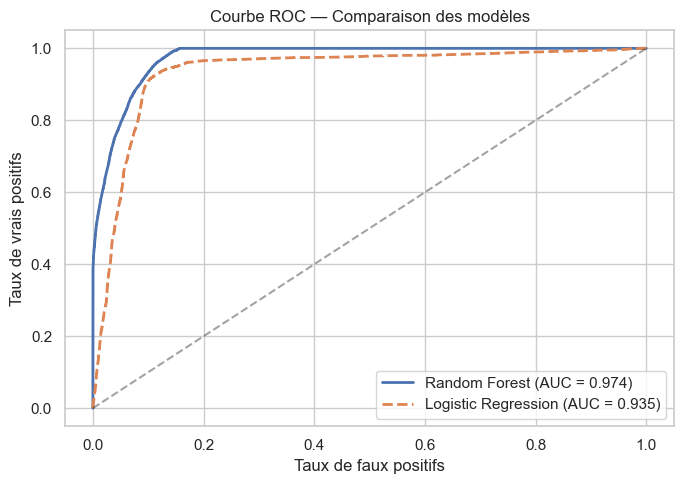

In [27]:
# Courbe ROC
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

auc_rf = auc(fpr_rf, tpr_rf)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", linewidth=2)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})", linewidth=2, linestyle="--")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC — Comparaison des modèles")
plt.legend()
plt.tight_layout()
plt.show()


INSIGHT:4Le Random Forest obtient la meilleure performance avec une AUC de 0,974 contre 0,935 pour la Régression Logistique.

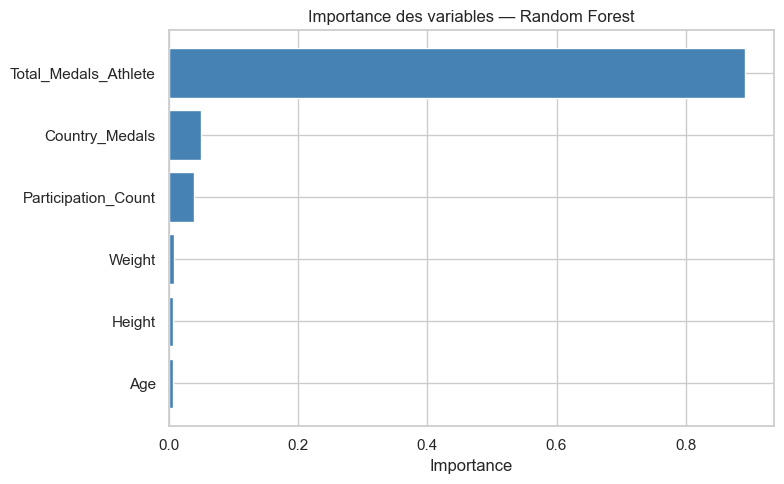

,Feature,Importance
4,Total_Medals_Athlete,0.892114
5,Country_Medals,0.049260
3,Participation_Count,0.038411
2,Weight,0.008213
1,Height,0.006501
0,Age,0.005501


In [28]:
# Importance des variables — Random Forest
importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Importance des variables — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importance_df


Total_Medals_Athlete est la variable la plus influente (89,2 %), montrant que les performances passées sont le meilleur indicateur des résultats futurs.

## 8. Clustering K-Means — Segmentation des athlètes

Objectif : segmenter les athlètes en profils homogènes selon leur âge, morphologie et expérience.

Features utilisées : `Age`, `Height`, `Weight`, `Participation_Count`, `Total_Medals_Athlete`.  
Le nombre optimal de clusters est déterminé par la **méthode du coude** (K=3 retenu).

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Variables utilisées pour le clustering
CLUSTER_FEATURES = ["Age", "Height", "Weight", "Participation_Count", "Total_Medals_Athlete"]

df_cluster = df[CLUSTER_FEATURES].dropna().copy()

# Normalisation
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df_cluster)

print(f"Nombre d athlètes pour le clustering : {len(df_cluster)}")
print(f"Variables utilisées : {CLUSTER_FEATURES}")

Nombre d athlètes pour le clustering : 269689
Variables utilisées : ['Age', 'Height', 'Weight', 'Participation_Count', 'Total_Medals_Athlete']


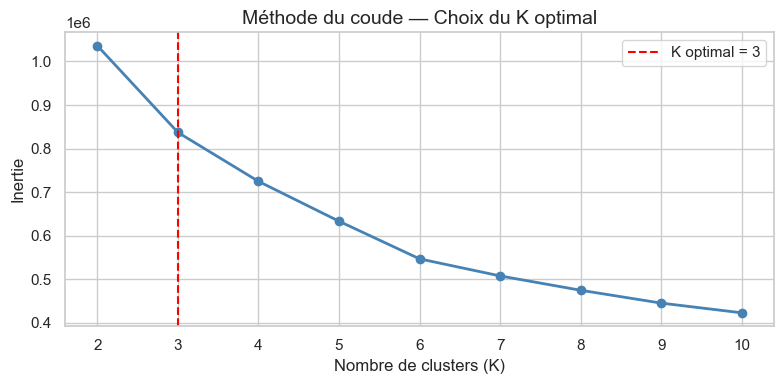

K = 3 clusters retenu (coude visible)


In [30]:
# MÉTHODE DU COUDE 
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker="o", color="steelblue", linewidth=2)
plt.axvline(x=3, color="red", linestyle="--", label="K optimal = 3")
plt.title("Méthode du coude — Choix du K optimal", fontsize=14)
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.legend()
plt.tight_layout()
plt.show()
print("K = 3 clusters retenu (coude visible)")

La méthode du coude identifie K = 3 comme nombre optimal de clusters pour segmenter les athlètes.

In [31]:
# APPLICATION K-MEANS avec K=3 
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster["Cluster"] = kmeans.fit_predict(X_cluster)

df_cluster_index = df[CLUSTER_FEATURES].dropna().index
df.loc[df_cluster_index, "Cluster"] = df_cluster["Cluster"].values

print("=== Répartition des clusters ===")
print(df_cluster["Cluster"].value_counts().sort_index())


=== Répartition des clusters ===
Cluster
0    134436
1     23946
2    111307
Name: count, dtype: int64


In [32]:
#  ANALYSE DES CLUSTERS 
cluster_profile = df_cluster.groupby("Cluster")[CLUSTER_FEATURES].mean().round(2)
cluster_profile["Nb_Athletes"] = df_cluster.groupby("Cluster").size()

cluster_profile.index = ["Cluster 0 — Débutants", 
                          "Cluster 1 — Intermédiaires", 
                          "Cluster 2 — Performants"]

print("=== Profils moyens par cluster ===")
print(cluster_profile.to_string())


=== Profils moyens par cluster ===
                              Age  Height  Weight  Participation_Count  Total_Medals_Athlete  Nb_Athletes
Cluster 0 — Débutants       23.41  169.41   62.45                 3.27                  0.48       134436
Cluster 1 — Intermédiaires  26.87  171.03   65.56                13.56                  6.12        23946
Cluster 2 — Performants     27.67  183.02   81.33                 2.73                  0.82       111307


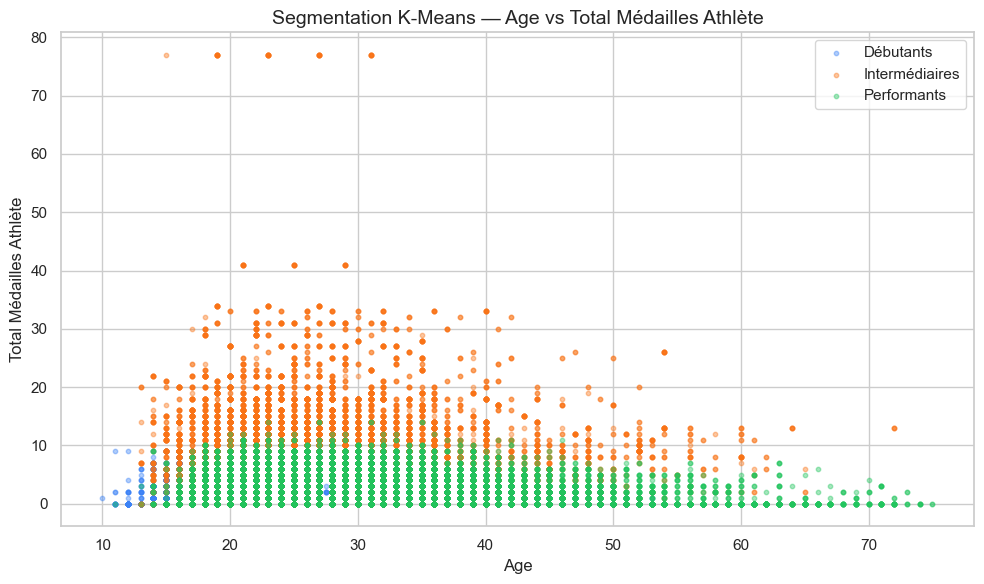

In [33]:
# Scatter plot Age vs Total_Medals_Athlete
colors = ["#3b82f6", "#f97316", "#22c55e"]
labels = ["Débutants", "Intermédiaires", "Performants"]

plt.figure(figsize=(10, 6))
for i in range(3):
    mask = df_cluster["Cluster"] == i
    plt.scatter(
        df_cluster.loc[mask, "Age"],
        df_cluster.loc[mask, "Total_Medals_Athlete"],
        c=colors[i], label=labels[i], alpha=0.4, s=10
    )

plt.title("Segmentation K-Means — Age vs Total Médailles Athlète", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Total Médailles Athlète")
plt.legend()
plt.tight_layout()
plt.show()


INSIGHT:La segmentation met en évidence trois profils distincts d'athlètes. Les athlètes du cluster Intermédiaires concentrent le plus grand nombre de médailles, tandis que les Débutants possèdent peu d'expérience et peu de récompenses. Les Performants se distinguent par une présence importante dans les compétitions et des résultats plus réguliers.

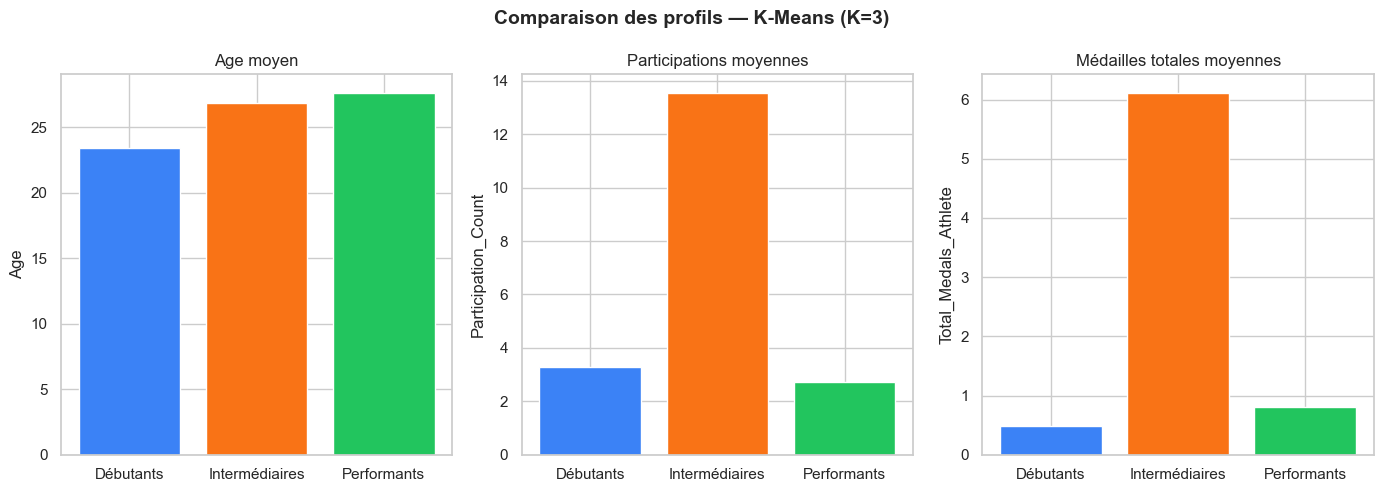

In [34]:
#  Barplot profils moyens 
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ["Age", "Participation_Count", "Total_Medals_Athlete"]
titles = ["Age moyen", "Participations moyennes", "Médailles totales moyennes"]

for ax, metric, title in zip(axes, metrics, titles):
    values = df_cluster.groupby("Cluster")[metric].mean()
    ax.bar(["Débutants", "Intermédiaires", "Performants"], values,
           color=["#3b82f6", "#f97316", "#22c55e"])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)

plt.suptitle("Comparaison des profils — K-Means (K=3)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Interprétation des clusters

| Cluster | Profil | Caractéristiques |
|---|---|---|
| Cluster 0 | **Débutants** | Peu de participations, peu de médailles, jeunes |
| Cluster 1 | **Intermédiaires** | Profil physique moyen, quelques participations |
| Cluster 2 | **Performants** | Expérimentés, score de médailles élevé |

**Conclusion :** L'expérience (Participation_Count) est le facteur le plus discriminant entre les clusters.
Les athlètes du Cluster 2 concentrent la majorité des médailles, confirmant que l'expérience est un facteur clé de succès olympique.

## 9. Prédictions JO 2028

### Approche de prédiction

La prédiction est construite en deux étapes :

1. **Calcul du taux de croissance** par pays sur les 4 dernières olympiades d'été (plafonné à ±50%)
2. **Projection 2028** : médailles de la dernière olympiade × (1 + taux de croissance)

Seuls les JO d'été (`Season == "Summer"`) sont utilisés, car Los Angeles 2028 est une olympiade estivale.


In [35]:

df_summer = df[df["Season"] == "Summer"].copy()

country_year = (df_summer.groupby(["NOC", "Year"])["Has_Medal"]
                .sum()
                .reset_index()
                .rename(columns={"Has_Medal": "Medals"}))

recent_years = sorted(country_year["Year"].unique())[-4:]
print(f"Olympiades utilisées pour la projection : {recent_years}")

df_recent = country_year[country_year["Year"].isin(recent_years)].copy()

pivot = df_recent.pivot_table(index="NOC", columns="Year", values="Medals", fill_value=0)
pivot.columns = [str(c) for c in pivot.columns]

years_sorted = sorted([c for c in pivot.columns])
if len(years_sorted) >= 2:
    pivot["growth_rate"] = (
        (pivot[years_sorted[-1]] - pivot[years_sorted[0]])
        / pivot[years_sorted[0]].replace(0, np.nan)
    ).fillna(0).clip(-0.5, 1.0)   # on plafonne la croissance à ±50%

# Score historique global
hist_score = (df_summer.groupby("NOC")["Medal_Score"]
              .sum()
              .reset_index()
              .rename(columns={"Medal_Score": "Hist_Score"}))

pivot = pivot.reset_index().merge(hist_score, on="NOC", how="left")

last_year_col = years_sorted[-1]
pivot["Predicted_2028"] = (
    pivot[last_year_col] * (1 + pivot["growth_rate"])
).round(1)

top_2028 = pivot.sort_values("Predicted_2028", ascending=False).head(10)

print("\nTop 10 pays prédits pour 2028 :")
print(top_2028[["NOC", last_year_col, "growth_rate", "Predicted_2028"]].to_string(index=False))


Olympiades utilisées pour la projection : [np.int64(2004), np.int64(2008), np.int64(2012), np.int64(2016)]

Top 10 pays prédits pour 2028 :
NOC  2016  growth_rate  Predicted_2028
GBR 145.0     1.000000           290.0
USA 264.0     0.003802           265.0
FRA  96.0     0.811321           173.9
GER 159.0     0.067114           169.7
CAN  69.0     1.000000           138.0
CHN 113.0     0.202128           135.8
SRB  54.0     1.000000           108.0
NZL  36.0     1.000000            72.0
RUS 115.0    -0.391534            70.0
ESP  45.0     0.500000            67.5


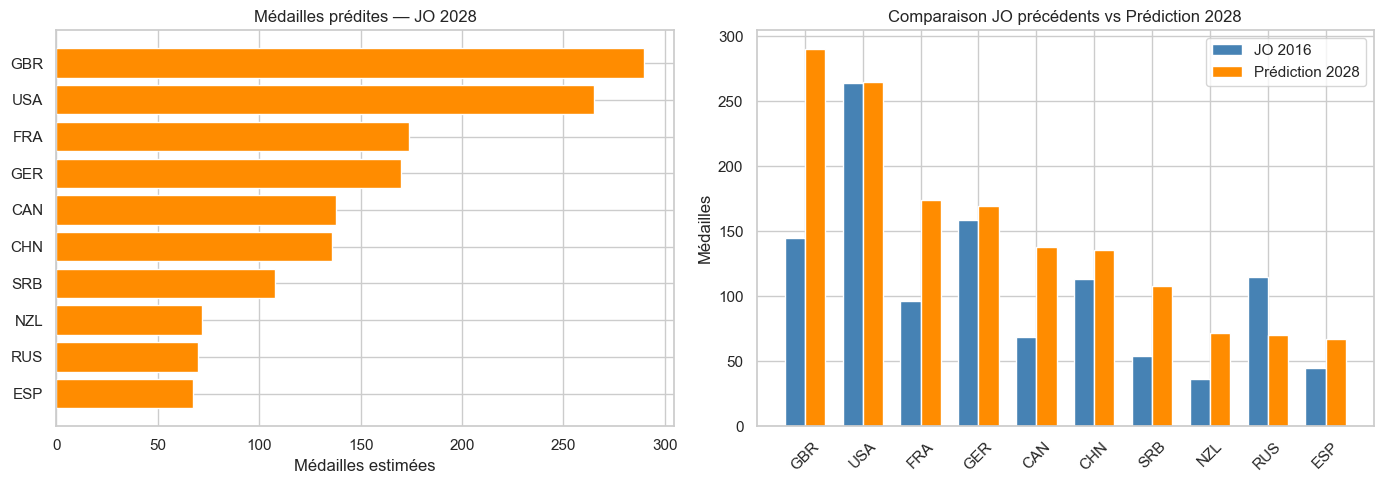

In [36]:
# Visualisation des prédictions JO 2028
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Médailles prédites
axes[0].barh(top_2028["NOC"], top_2028["Predicted_2028"], color="darkorange")
axes[0].invert_yaxis()
axes[0].set_title("Médailles prédites — JO 2028")
axes[0].set_xlabel("Médailles estimées")

# Comparaison dernière olympiade vs 2028
x = np.arange(len(top_2028))
width = 0.35
axes[1].bar(x - width/2, top_2028[last_year_col], width, label=f"JO {last_year_col}", color="steelblue")
axes[1].bar(x + width/2, top_2028["Predicted_2028"], width, label="Prédiction 2028", color="darkorange")
axes[1].set_xticks(x)
axes[1].set_xticklabels(top_2028["NOC"], rotation=45)
axes[1].set_title("Comparaison JO précédents vs Prédiction 2028")
axes[1].set_ylabel("Médailles")
axes[1].legend()

plt.tight_layout()
plt.show()


Les pays historiquement performants conservent leur domination dans les prédictions JO 2028, avec le Royaume-Uni, les États-Unis et la France en tête

## Limites et biais du modèle

### Limites techniques
- **Données arrêtées à 2016** : les performances récentes (Rio 2016 est la dernière olympiade) ne sont pas intégrées, ce qui peut biaiser les projections 2028
- **Pas de données contextuelles** : blessures, retraites, changements de fédération, dopages ne sont pas pris en compte
- **Features physiques limitées** : âge, taille et poids sont des proxies imparfaits de la performance réelle

### Limites du remapping géopolitique
- Le remapping URS→RUS ou GDR→GER est une **approximation** : les athlètes soviétiques n'étaient pas nécessairement russes
- Cela peut **surestimer** le palmarès historique de la Russie et de l'Allemagne

### Limites des prédictions 2028
- Les prédictions sont basées sur du **momentum passé** et ne capturent pas les discontinuités (nouveau talent, effondrement d'un programme sportif)
- Le modèle ne tient pas compte de **l'avantage à domicile** des États-Unis pour Los Angeles 2028

### Ce qu'on ferait avec plus de temps
- Intégrer les données des JO 2024 (Paris)
- Ajouter des données socio-économiques par pays (budget sportif, PIB)
- Tester des modèles plus avancés (XGBoost, LightGBM)
- Construire un modèle par discipline sportive plutôt qu'un modèle global

## 10. Conclusion

### Résultats clés

- **Les États-Unis** restent le pays le plus performant historiquement et le favori pour 2028 (Los Angeles — avantage à domicile potentiel)
- **La Chine et la Grande-Bretagne** montrent une progression constante sur les olympiades récentes
- **L'expérience** (`Participation_Count`) et **l'historique de médailles du pays** sont les variables les plus prédictives
- Le modèle **Random Forest** surpasse la Régression Logistique (AUC plus élevée, meilleur F1 sur la classe médaillés)

### Limites du modèle
- Ne prend pas en compte les blessures, retraites ou nouvelles générations
- Le remapping des pays disparus est une approximation géopolitique
- Les données s'arrêtent avant les JO 2024 — les tendances très récentes ne sont pas captées
- Les prédictions restent probabilistes et indicatives

### Recommandations 
- Surveiller les pays en forte croissance (Australie, Pays-Bas, Kenya)
- Investir dans les disciplines à fort volume de médailles (Athlétisme, Natation)
- Intégrer les données de 2024 pour actualiser les projections
